Step 1: Preprocessing...
  Image size: (480, 640, 3)
Step 2: Segmenting (resized to 320px)...
  Found 10 cells
Step 3: Drawing results...


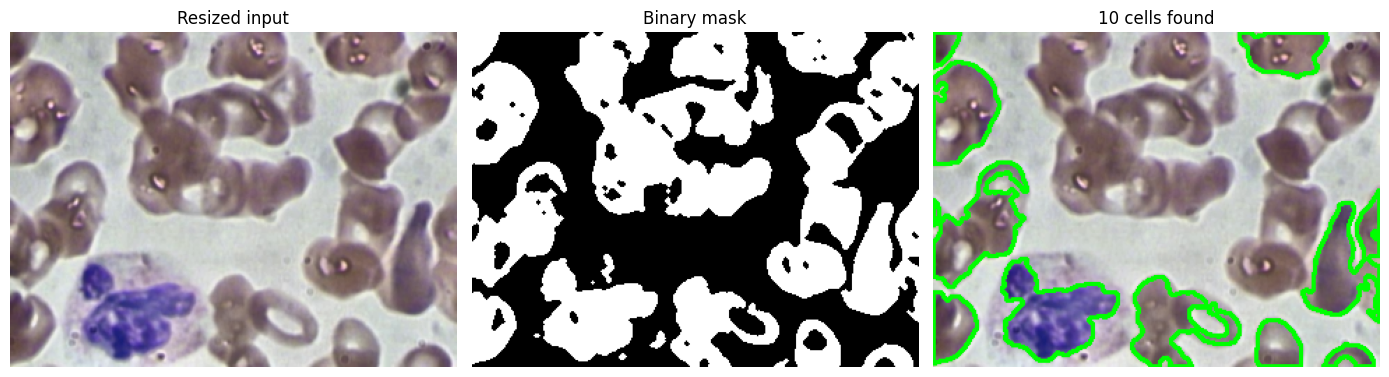

Done! Image saved to outputs/segmentation_result.png


: 

In [ ]:
import sys
sys.path.append('../src')
import cv2
import matplotlib.pyplot as plt
from preprocessing import preprocess_image
from segmentation import segment_image

img_path = '../data/BCCD/train/img/BloodImage_00001.jpeg'

print("Step 1: Preprocessing...")
processed = preprocess_image(img_path)
print(f"  Image size: {processed.shape}")

print("Step 2: Segmenting (resized to 320px)...")
contours, markers, clean, resized = segment_image(processed, max_size=320)
print(f"  Found {len(contours)} cells")

print("Step 3: Drawing results...")
result = resized.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[0].set_title('Resized input')
axes[0].axis('off')

axes[1].imshow(clean, cmap='gray')
axes[1].set_title('Binary mask')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'{len(contours)} cells found')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/segmentation_result.png')
plt.show()
print("Done! Image saved to outputs/segmentation_result.png")

Found 7 cells


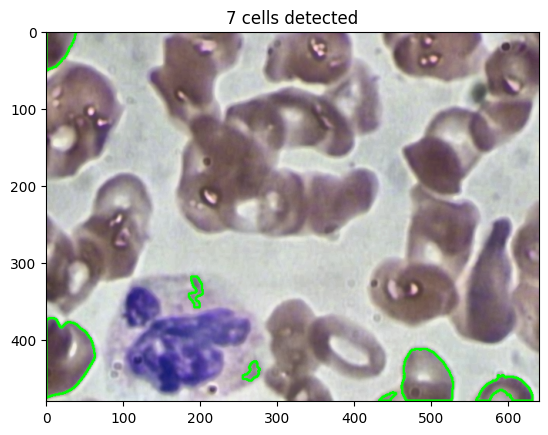

In [1]:
import sys
sys.path.append('../src')
import cv2
import matplotlib.pyplot as plt
from preprocessing import preprocess_image
from segmentation import segment_image

img_path = '../data/BCCD/train/img/BloodImage_00001.jpeg'
processed = preprocess_image(img_path)
contours, markers, clean = segment_image(processed)

# draw contours on image
result = processed.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)
print(f"Found {len(contours)} cells")

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'{len(contours)} cells detected')
plt.savefig('../outputs/segmentation_result.png')
plt.show()